In [1]:
from statsbombpy import sb
import pandas as pd
import duckdb as db
import warnings
from statsbombpy.api_client import NoAuthWarning
warnings.filterwarnings("ignore", category=NoAuthWarning)

con = db.connect("statsbomb.db")

def query(sql):
    return con.execute(sql).df()

In [2]:
import os
from dotenv import load_dotenv

load_dotenv(override=True)

required_keys = ["R2_ACCESS_KEY_ID", "R2_SECRET_ACCESS_KEY", "R2_ACCOUNT_ID", "R2_BUCKET"]
missing = [k for k in required_keys if not os.getenv(k)]

if missing:
    print(f"Missing credentials: {missing}")
else:
    print("All R2 credentials loaded successfully.")

All R2 credentials loaded successfully.


In [5]:
con.execute("INSTALL httpfs;")
con.execute("LOAD httpfs;")

account_id = os.getenv("R2_ACCOUNT_ID")
access_key = os.getenv("R2_ACCESS_KEY_ID")
secret_key = os.getenv("R2_SECRET_ACCESS_KEY")
bucket     = os.getenv("R2_BUCKET")

con.execute(f"""
    CREATE OR REPLACE SECRET r2_secret (
        TYPE S3,
        KEY_ID '{access_key}',
        SECRET '{secret_key}',
        ENDPOINT '{account_id}.r2.cloudflarestorage.com',
        REGION 'auto',
        URL_STYLE 'path'
    );
""")

print("httpfs loaded and R2 secret created.")

httpfs loaded and R2 secret created.


In [7]:
con.execute(f"""
    CREATE OR REPLACE VIEW events_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/events/**/*.parquet',
        hive_partitioning=true, union_by_name=true)
""")

con.execute(f"""
    CREATE OR REPLACE VIEW matches_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/matches/**/*.parquet',
        hive_partitioning=true, union_by_name=true)
""")

con.execute(f"""
    CREATE OR REPLACE VIEW competitions_r2 AS
    SELECT * FROM read_parquet('s3://{bucket}/competitions/competitions.parquet')
""")

print("R2 views created.")

#for view in ["events_r2", "matches_r2", "competitions_r2"]:
#    count = con.execute(f"SELECT COUNT(*) FROM {view}").fetchone()[0]
#    print(f"  {view}: {count} rows")

R2 views created.


In [9]:
shots_sample = query("""
  SELECT *
  FROM events_r2
  WHERE type_name = 'Shot'
  LIMIT 5
""")

shots_sample.columns.tolist()

['bad_behaviour_card',
 'ball_receipt_outcome',
 'ball_recovery_recovery_failure',
 'carry_end_location',
 'clearance_aerial_won',
 'clearance_body_part',
 'clearance_head',
 'clearance_left_foot',
 'clearance_right_foot',
 'counterpress',
 'dribble_nutmeg',
 'dribble_outcome',
 'dribble_overrun',
 'duel_outcome',
 'duel_type',
 'duration',
 'foul_committed_advantage',
 'foul_committed_card',
 'foul_committed_offensive',
 'foul_committed_type',
 'foul_won_advantage',
 'foul_won_defensive',
 'goalkeeper_body_part',
 'goalkeeper_end_location',
 'goalkeeper_outcome',
 'goalkeeper_position',
 'goalkeeper_shot_saved_to_post',
 'goalkeeper_technique',
 'goalkeeper_type',
 'id',
 'index',
 'interception_outcome',
 'match_id',
 'minute',
 'miscontrol_aerial_won',
 'off_camera',
 'out',
 'pass_aerial_won',
 'pass_angle',
 'pass_assisted_shot_id',
 'pass_body_part',
 'pass_cross',
 'pass_cut_back',
 'pass_deflected',
 'pass_end_location',
 'pass_goal_assist',
 'pass_height',
 'pass_inswinging',


In [27]:
import numpy as np

shots = query("""
  SELECT
      location_x,
      location_y,
      shot_body_part,
      shot_type,
      shot_technique,
      shot_first_time,
      shot_aerial_won,
      shot_one_on_one,
      shot_open_goal,
      shot_follows_dribble,
      under_pressure,
      shot_outcome,
      shot_statsbomb_xg
  FROM events_r2
  WHERE type_name = 'Shot'
  AND shot_type != 'Penalty'
  AND competition_id != 11
""")

shots["goal"] = (shots["shot_outcome"] == "Goal").astype(int)

shots["distance"] = np.sqrt((shots["location_x"] - 120)**2 + (shots["location_y"] - 40)**2)

a = np.array([120 - shots["location_x"], 36 - shots["location_y"]]).T
b = np.array([120 - shots["location_x"], 44 - shots["location_y"]]).T
dot = (a * b).sum(axis=1)
cross = a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]
shots["angle"] = np.arctan2(np.abs(cross), dot)

shots = shots.dropna(subset=["location_x", "location_y", "shot_outcome"])

print(shots.shape)
print(shots["goal"].value_counts())

(33759, 16)
goal
0    30625
1     3134
Name: count, dtype: int64


In [29]:
from sklearn.model_selection import train_test_split
import xgboost as xgb

bool_cols = [
  "shot_first_time", "shot_aerial_won", "shot_one_on_one",
  "shot_open_goal", "under_pressure"
]
cat_cols = ["shot_body_part", "shot_type", "shot_technique"]

for col in bool_cols:
  shots[col] = shots[col].fillna(False).astype(int)

shots_encoded = pd.get_dummies(shots, columns=cat_cols)

feature_cols = (
  ["distance", "angle"] +
  bool_cols +
  [c for c in shots_encoded.columns if c.startswith(tuple(cat_cols))]
)

X = shots_encoded[feature_cols]
y = shots_encoded["goal"]

X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Features: {feature_cols}")

Train: (27007, 21), Test: (6752, 21)
Features: ['distance', 'angle', 'shot_first_time', 'shot_aerial_won', 'shot_one_on_one', 'shot_open_goal', 'under_pressure', 'shot_body_part_Head', 'shot_body_part_Left Foot', 'shot_body_part_Other', 'shot_body_part_Right Foot', 'shot_type_Corner', 'shot_type_Free Kick', 'shot_type_Open Play', 'shot_technique_Backheel', 'shot_technique_Diving Header', 'shot_technique_Half Volley', 'shot_technique_Lob', 'shot_technique_Normal', 'shot_technique_Overhead Kick', 'shot_technique_Volley']


In [31]:
 model = xgb.XGBClassifier(
  n_estimators=500,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=50
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[50]	validation_0-logloss:0.51918
[100]	validation_0-logloss:0.51323
[150]	validation_0-logloss:0.50924
[200]	validation_0-logloss:0.50626
[250]	validation_0-logloss:0.50391
[300]	validation_0-logloss:0.50152
[350]	validation_0-logloss:0.49890
[400]	validation_0-logloss:0.49714
[450]	validation_0-logloss:0.49431
[499]	validation_0-logloss:0.49253
Best iteration: 499


In [33]:
 model = xgb.XGBClassifier(
  n_estimators=1000,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=100
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[100]	validation_0-logloss:0.51323
[200]	validation_0-logloss:0.50626
[300]	validation_0-logloss:0.50152
[400]	validation_0-logloss:0.49714
[500]	validation_0-logloss:0.49251
[600]	validation_0-logloss:0.48954
[700]	validation_0-logloss:0.48638
[800]	validation_0-logloss:0.48362
[900]	validation_0-logloss:0.48176
[999]	validation_0-logloss:0.48030
Best iteration: 999


In [35]:
 model = xgb.XGBClassifier(
  n_estimators=2000,
  learning_rate=0.1,
  max_depth=4,
  scale_pos_weight=30734/3452,
  objective="binary:logistic",
  eval_metric="logloss",
  early_stopping_rounds=20,
  random_state=42
)

model.fit(
  X_train, y_train,
  eval_set=[(X_test, y_test)],
  verbose=200
)

print(f"Best iteration: {model.best_iteration}")

[0]	validation_0-logloss:0.63610
[200]	validation_0-logloss:0.50626
[400]	validation_0-logloss:0.49714
[600]	validation_0-logloss:0.48954
[800]	validation_0-logloss:0.48362
[1000]	validation_0-logloss:0.48028
[1200]	validation_0-logloss:0.47664
[1232]	validation_0-logloss:0.47647
Best iteration: 1212


In [39]:
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss

y_pred_proba = model.predict_proba(X_test)[:, 1]

auc   = roc_auc_score(y_test, y_pred_proba)
brier = brier_score_loss(y_test, y_pred_proba)
ll    = log_loss(y_test, y_pred_proba)

sb_auc   = roc_auc_score(y_test, shots_encoded.loc[X_test.index, "shot_statsbomb_xg"])
sb_brier = brier_score_loss(y_test, shots_encoded.loc[X_test.index, "shot_statsbomb_xg"])

print("Our model:")
print(f"  AUC:         {auc:.4f}")
print(f"  Brier score: {brier:.4f}")
print(f"  Log loss:    {ll:.4f}")
print()
print("StatsBomb xG:")
print(f"  AUC:         {sb_auc:.4f}")
print(f"  Brier score: {sb_brier:.4f}")


Our model:
  AUC:         0.7430
  Brier score: 0.1562
  Log loss:    0.4764

StatsBomb xG:
  AUC:         0.8122
  Brier score: 0.0686


In [59]:
from sklearn.calibration import CalibratedClassifierCV

X_cal, X_eval, y_cal, y_eval = train_test_split(
  X_test, y_test, test_size=0.5, stratify=y_test, random_state=42
)

calibrated_model = CalibratedClassifierCV(model, cv="prefit", method="isotonic")
calibrated_model.fit(X_cal, y_cal)

y_pred_calibrated = calibrated_model.predict_proba(X_eval)[:, 1]

auc_cal   = roc_auc_score(y_eval, y_pred_calibrated)
brier_cal = brier_score_loss(y_eval, y_pred_calibrated)
sb_brier_cal = brier_score_loss(y_eval, shots_encoded.loc[X_eval.index, "shot_statsbomb_xg"])

print("Calibrated model:")
print(f"  AUC:         {auc_cal:.4f}")
print(f"  Brier score: {brier_cal:.4f}")
print()
print("StatsBomb xG (same eval set):")
print(f"  Brier score: {sb_brier_cal:.4f}")


Calibrated model:
  AUC:         0.7384
  Brier score: 0.0738

StatsBomb xG (same eval set):
  Brier score: 0.0670


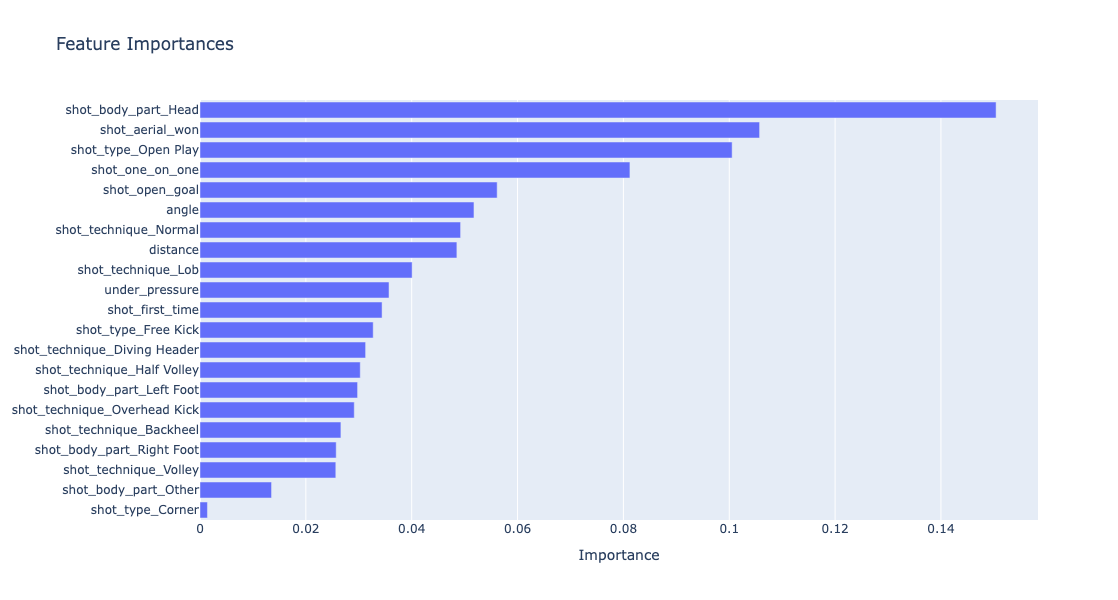

In [61]:
import plotly.graph_objects as go

importances = pd.Series(
  model.feature_importances_,
  index=feature_cols
).sort_values(ascending=True)

fig = go.Figure(go.Bar(
  x=importances.values,
  y=importances.index,
  orientation="h"
))

fig.update_layout(
  title="Feature Importances",
  xaxis_title="Importance",
  height=600
)

fig.show()

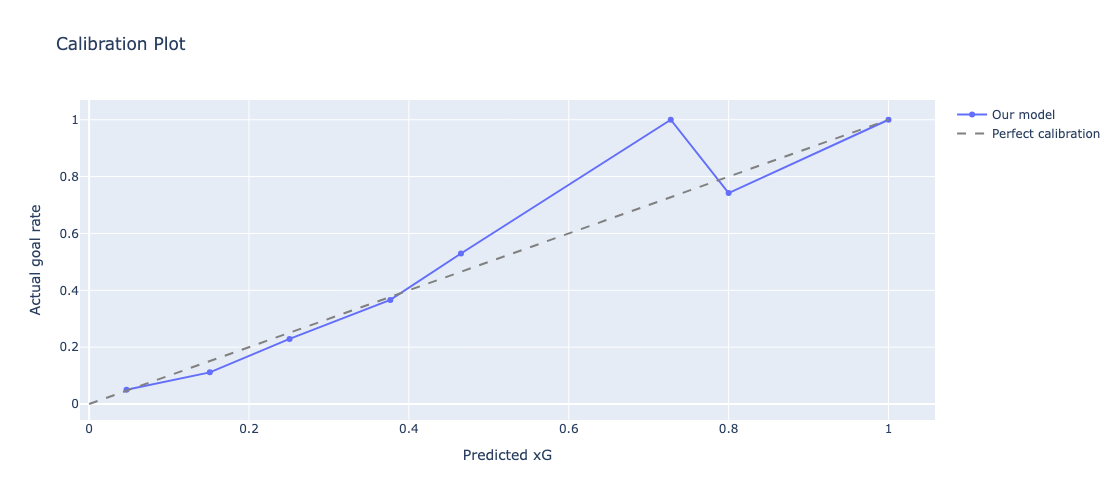

In [63]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_eval, y_pred_calibrated, n_bins=10)

fig = go.Figure()

fig.add_trace(go.Scatter(
  x=prob_pred, y=prob_true,
  mode="lines+markers",
  name="Our model"
))

fig.add_trace(go.Scatter(
  x=[0, 1], y=[0, 1],
  mode="lines",
  name="Perfect calibration",
  line=dict(dash="dash", color="gray")
))

fig.update_layout(
  title="Calibration Plot",
  xaxis_title="Predicted xG",
  yaxis_title="Actual goal rate",
  width=600,
  height=500
)

fig.show()

In [65]:
import joblib

joblib.dump(calibrated_model, "xg_model.pkl")
joblib.dump(feature_cols, "xg_feature_cols.pkl")

print("Model saved.")


Model saved.


In [71]:
match_options = query("""
  SELECT
      m.match_id,
      m.home_team,
      m.away_team,
      m.home_score,
      m.away_score,
      m.competition_id
  FROM matches_r2 m
  WHERE m.match_id IN (
      SELECT DISTINCT match_id FROM events_r2
      WHERE type_name = 'Shot'
      AND competition_id != 11
  )
  LIMIT 20
""")

match_options

,match_id,home_team,away_team,home_score,away_score,competition_id
0,3877060,New York Red Bulls,Inter Miami,0,2,44
1,3837928,Paris Saint-Germain,Lyon,0,1,7
2,3837947,Paris Saint-Germain,Lens,3,1,7
3,3802676,Paris Saint-Germain,Lens,1,1,7
4,3802837,Saint-Étienne,Paris Saint-Germain,1,3,7
5,3802805,OGC Nice,Paris Saint-Germain,1,0,7
6,3901241,Stade Malherbe Caen,Bastia,0,0,7
7,3900562,Stade Malherbe Caen,Paris Saint-Germain,0,3,7
8,3900596,Guingamp,Bastia,1,0,7
9,3901166,Paris Saint-Germain,Montpellier,0,0,7


In [73]:
match_id = 3837947

match_shots = query(f"""
  SELECT
      location_x,
      location_y,
      shot_body_part,
      shot_type,
      shot_technique,                                                                                                                                                                                                     
      shot_first_time,
      shot_aerial_won,
      shot_one_on_one,
      shot_open_goal,
      under_pressure,
      shot_outcome,
      shot_statsbomb_xg,
      player_name,
      team_name,                                                                                                                                                                                                          
      minute
  FROM events_r2
  WHERE type_name = 'Shot'
  AND match_id = {match_id}
  AND shot_type != 'Penalty'
""")

# encode
for col in bool_cols:                                                                                                                                                                                                       
  match_shots[col] = match_shots[col].fillna(False).astype(int)

match_shots_encoded = pd.get_dummies(match_shots, columns=cat_cols)
match_shots_encoded = match_shots_encoded.reindex(columns=feature_cols, fill_value=0)

# distance and angle
a = np.array([120 - match_shots["location_x"], 36 - match_shots["location_y"]]).T
b = np.array([120 - match_shots["location_x"], 44 - match_shots["location_y"]]).T
dot = (a * b).sum(axis=1)
cross = a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]
match_shots_encoded["distance"] = np.sqrt((match_shots["location_x"] - 120)**2 + (match_shots["location_y"] - 40)**2)
match_shots_encoded["angle"] = np.arctan2(np.abs(cross), dot)

match_shots["xg_pred"] = calibrated_model.predict_proba(match_shots_encoded[feature_cols])[:, 1]

print(match_shots[["player_name", "team_name", "minute", "shot_outcome", "xg_pred", "shot_statsbomb_xg"]])



                       player_name            team_name  minute  \
0                Salis Abdul Samed                 Lens       1   
1                Ikoma Loïs Openda                 Lens      10   
2   Lionel Andrés Messi Cuccittini  Paris Saint-Germain      12   
3                      Nuno Mendes  Paris Saint-Germain      26   
4             Kylian Mbappé Lottin  Paris Saint-Germain      29   
5           Vitor Machado Ferreira  Paris Saint-Germain      29   
6             Kylian Mbappé Lottin  Paris Saint-Germain      30   
7            Przemysław Frankowski                 Lens      32   
8                      Kevin Danso                 Lens      33   
9             Kylian Mbappé Lottin  Paris Saint-Germain      35   
10          Vitor Machado Ferreira  Paris Saint-Germain      36   
11  Lionel Andrés Messi Cuccittini  Paris Saint-Germain      39   
12  Lionel Andrés Messi Cuccittini  Paris Saint-Germain      42   
13               Ikoma Loïs Openda                 Lens      4

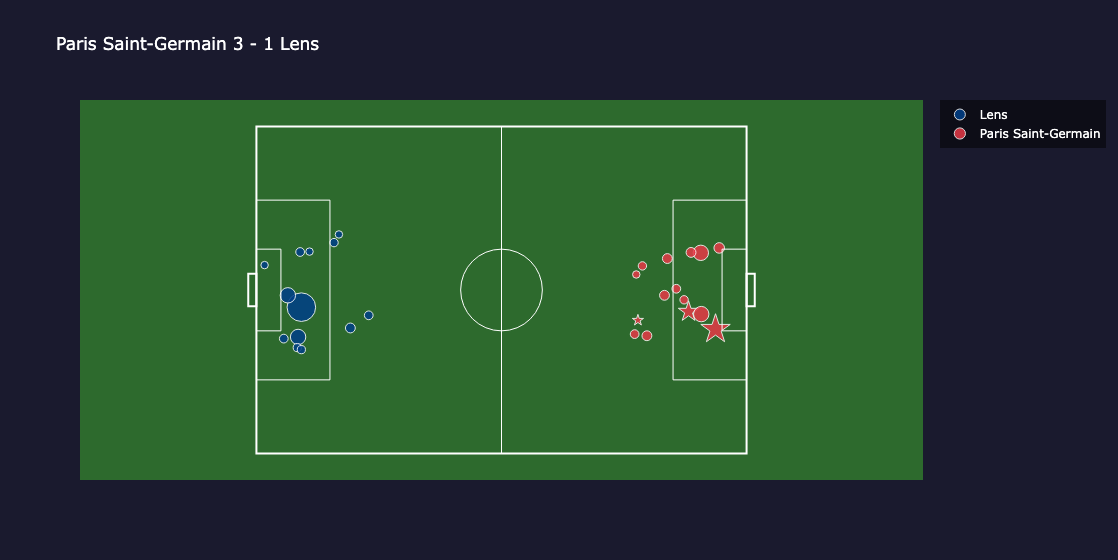

In [75]:
match_info = query(f"""
  SELECT home_team, away_team, home_score, away_score
  FROM matches_r2
  WHERE match_id = {match_id}
""").iloc[0]

teams = match_shots["team_name"].unique()
colors = {teams[0]: "#003f88", teams[1]: "#e63946"}

fig = go.Figure()

# pitch outline
fig.add_shape(type="rect", x0=0, y0=0, x1=120, y1=80, line=dict(color="white", width=2))
# penalty areas
fig.add_shape(type="rect", x0=102, y0=18, x1=120, y1=62, line=dict(color="white", width=1))
fig.add_shape(type="rect", x0=0, y0=18, x1=18, y1=62, line=dict(color="white", width=1))
# six yard boxes
fig.add_shape(type="rect", x0=114, y0=30, x1=120, y1=50, line=dict(color="white", width=1))
fig.add_shape(type="rect", x0=0, y0=30, x1=6, y1=50, line=dict(color="white", width=1))
# centre circle
fig.add_shape(type="circle", x0=50, y0=30, x1=70, y1=50, line=dict(color="white", width=1))
# halfway line
fig.add_shape(type="line", x0=60, y0=0, x1=60, y1=80, line=dict(color="white", width=1))
# goals
fig.add_shape(type="rect", x0=120, y0=36, x1=122, y1=44, line=dict(color="white", width=2))
fig.add_shape(type="rect", x0=-2, y0=36, x1=0, y1=44, line=dict(color="white", width=2))

for team in teams:
  team_shots = match_shots[match_shots["team_name"] == team].copy()
  # mirror away team shots to attack right→left
  if team == match_info["away_team"]:
      team_shots["location_x"] = 120 - team_shots["location_x"]
      team_shots["location_y"] = 80 - team_shots["location_y"]

  is_goal = team_shots["shot_outcome"] == "Goal"

  fig.add_trace(go.Scatter(
      x=team_shots["location_x"],                                                                                                                                                                                         
      y=team_shots["location_y"],
      mode="markers",
      name=team,
      marker=dict(
          size=team_shots["xg_pred"] * 60 + 6,
          color=colors[team],
          symbol=["star" if g else "circle" for g in is_goal],
          line=dict(color="white", width=1),
          opacity=0.85
      ),
      text=[
          f"{row.player_name}<br>Min {row.minute}<br>xG: {row.xg_pred:.2f}<br>{row.shot_outcome}"
          for _, row in team_shots.iterrows()
      ],
      hoverinfo="text"
  ))

fig.update_layout(
  title=f"{match_info['home_team']} {match_info['home_score']} - {match_info['away_score']} {match_info['away_team']}",
  plot_bgcolor="#2d6a2d",
  paper_bgcolor="#1a1a2e",
  font=dict(color="white"),
  xaxis=dict(range=[-5, 125], showgrid=False, zeroline=False, visible=False),
  yaxis=dict(range=[-5, 85], showgrid=False, zeroline=False, visible=False, scaleanchor="x", scaleratio=1),
  legend=dict(bgcolor="rgba(0,0,0,0.5)"),
  width=800,
  height=560
)

fig.show()


In [77]:
goals = query(f"""
  SELECT                                                                                                                                                                                                                  
      player_name,
      team_name,
      minute,
      shot_outcome,
      shot_type
  FROM events_r2
  WHERE match_id = {match_id}
  AND type_name = 'Shot'
  AND shot_outcome = 'Goal'
""")

goals


,player_name,team_name,minute,shot_outcome,shot_type
0,Kylian Mbappé Lottin,Paris Saint-Germain,30,Goal,Open Play
1,Vitor Machado Ferreira,Paris Saint-Germain,36,Goal,Open Play
2,Lionel Andrés Messi Cuccittini,Paris Saint-Germain,39,Goal,Open Play
3,Przemysław Frankowski,Lens,59,Goal,Penalty


In [79]:
all_shots = query("""
  SELECT
      e.match_id,
      e.team_id,                                                                                                                                                                                                          
      e.team_name,
      e.minute,
      e.second,
      e.period,
      e.shot_outcome,
      e.shot_type,
      e.location_x,                                                                                                                                                                                                       
      e.location_y,
      e.shot_body_part,
      e.shot_technique,
      e.shot_first_time,
      e.shot_aerial_won,
      e.shot_one_on_one,
      e.shot_open_goal,
      e.under_pressure,
      m.home_team,
      m.away_team,
      m.home_team_id,
      m.away_team_id,
      m.home_score,                                                                                                                                                                                                       
      m.away_score
  FROM events_r2 e
  JOIN matches_r2 m ON e.match_id = m.match_id
  WHERE e.type_name = 'Shot'
  AND e.competition_id != 11
""")

print(all_shots.shape)
all_shots.head()


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(34186, 23)


,match_id,team_id,team_name,minute,second,period,shot_outcome,shot_type,location_x,location_y,...,shot_aerial_won,shot_one_on_one,shot_open_goal,under_pressure,home_team,away_team,home_team_id,away_team_id,home_score,away_score
0,3878540,240,Bologna,0,53,1,Blocked,Open Play,104.5,30.9,...,<NA>,<NA>,<NA>,True,Lazio,Bologna,236,240,2,1
1,3878540,240,Bologna,0,55,1,Off T,Open Play,93.1,42.3,...,<NA>,<NA>,<NA>,True,Lazio,Bologna,236,240,2,1
2,3878540,236,Lazio,9,32,1,Off T,Open Play,111.8,30.9,...,<NA>,True,<NA>,<NA>,Lazio,Bologna,236,240,2,1
3,3878540,236,Lazio,13,32,1,Saved,Open Play,94.3,33.1,...,<NA>,<NA>,<NA>,<NA>,Lazio,Bologna,236,240,2,1
4,3878540,236,Lazio,16,46,1,Goal,Open Play,103.1,37.9,...,<NA>,<NA>,<NA>,<NA>,Lazio,Bologna,236,240,2,1


In [81]:
all_shots.columns.tolist()



['match_id',
 'team_id',
 'team_name',
 'minute',
 'second',
 'period',
 'shot_outcome',
 'shot_type',
 'location_x',
 'location_y',
 'shot_body_part',
 'shot_technique',
 'shot_first_time',
 'shot_aerial_won',
 'shot_one_on_one',
 'shot_open_goal',
 'under_pressure',
 'home_team',
 'away_team',
 'home_team_id',
 'away_team_id',
 'home_score',
 'away_score']

In [85]:
 # predict xG for all shots
for col in bool_cols:
  all_shots[col] = all_shots[col].fillna(False).astype(int)

all_shots_encoded = pd.get_dummies(all_shots, columns=cat_cols)
all_shots_encoded = all_shots_encoded.reindex(columns=feature_cols, fill_value=0)

a = np.array([120 - all_shots["location_x"], 36 - all_shots["location_y"]]).T
b = np.array([120 - all_shots["location_x"], 44 - all_shots["location_y"]]).T
dot = (a * b).sum(axis=1)
cross = a[:, 0] * b[:, 1] - a[:, 1] * b[:, 0]
all_shots_encoded["distance"] = np.sqrt((all_shots["location_x"] - 120)**2 + (all_shots["location_y"] - 40)**2)
all_shots_encoded["angle"] = np.arctan2(np.abs(cross), dot)

all_shots["xg_pred"] = calibrated_model.predict_proba(all_shots_encoded[feature_cols])[:, 1]

# identify home/away for each shot
all_shots["is_home"] = all_shots["team_id"] == all_shots["home_team_id"]

# sort chronologically within each match
all_shots = all_shots.sort_values(["match_id", "period", "minute", "second"]).reset_index(drop=True)

# cumulative xG and goals per team per match
all_shots["home_xg"] = all_shots.groupby("match_id").apply(
  lambda g: g["xg_pred"].where(g["is_home"]).fillna(0).cumsum()
).reset_index(level=0, drop=True)

all_shots["away_xg"] = all_shots.groupby("match_id").apply(
  lambda g: g["xg_pred"].where(~g["is_home"]).fillna(0).cumsum()
).reset_index(level=0, drop=True)

all_shots["home_goals"] = all_shots.groupby("match_id").apply(
  lambda g: (g["is_home"] & (g["shot_outcome"] == "Goal")).cumsum()
).reset_index(level=0, drop=True)

all_shots["away_goals"] = all_shots.groupby("match_id").apply(
  lambda g: (~g["is_home"] & (g["shot_outcome"] == "Goal")).cumsum()
).reset_index(level=0, drop=True)

print(all_shots[["match_id", "team_name", "minute", "xg_pred", "home_xg", "away_xg", "home_goals", "away_goals"]].head(20))




/var/folders/g_/zy97msqd5n13hj97lnsyfptm0000gn/T/ipykernel_34392/1292107873.py:24: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/g_/zy97msqd5n13hj97lnsyfptm0000gn/T/ipykernel_34392/1292107873.py:28: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

/var/folders/g_/zy97msqd5n13hj97lnsyfptm0000gn/T/ipykernel_34392/1292107873.py:32: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping 

    match_id                team_name  minute   xg_pred   home_xg   away_xg  \
0    3749052                  Arsenal       8  0.156556  0.000000  0.156556   
1    3749052                  Arsenal      12  0.036717  0.000000  0.193273   
2    3749052                  Arsenal      12  0.156556  0.000000  0.349829   
3    3749052  Wolverhampton Wanderers      13  0.064407  0.064407  0.349829   
4    3749052  Wolverhampton Wanderers      20  0.045570  0.109976  0.349829   
5    3749052                  Arsenal      21  0.045570  0.109976  0.395398   
6    3749052  Wolverhampton Wanderers      25  0.268750  0.378726  0.395398   
7    3749052                  Arsenal      36  0.024229  0.378726  0.419627   
8    3749052  Wolverhampton Wanderers      39  0.156556  0.535282  0.419627   
9    3749052  Wolverhampton Wanderers      43  0.268750  0.804032  0.419627   
10   3749052  Wolverhampton Wanderers      44  0.024229  0.828261  0.419627   
11   3749052                  Arsenal      45  0.156

/var/folders/g_/zy97msqd5n13hj97lnsyfptm0000gn/T/ipykernel_34392/1292107873.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [87]:
 # final outcome from home team perspective: 2=home win, 1=draw, 0=away win
all_shots["result"] = (
  (all_shots["home_score"] > all_shots["away_score"]).astype(int) * 2 +
  (all_shots["home_score"] == all_shots["away_score"]).astype(int)
)

# time remaining (standard match = 90 mins)
all_shots["minutes_remaining"] = (90 - all_shots["minute"]).clip(lower=0)

# game state features                                                                                                                                                                                                       
all_shots["goal_diff"] = all_shots["home_goals"] - all_shots["away_goals"]
all_shots["xg_diff"]   = all_shots["home_xg"] - all_shots["away_xg"]

wp_features = [
  "home_goals", "away_goals", "goal_diff",
  "home_xg", "away_xg", "xg_diff",
  "minute", "minutes_remaining", "period"
]

X_wp = all_shots[wp_features]
y_wp = all_shots["result"]

X_wp_train, X_wp_test, y_wp_train, y_wp_test = train_test_split(
  X_wp, y_wp, test_size=0.2, stratify=y_wp, random_state=42
)

print(y_wp.value_counts())
print(f"\nTrain: {X_wp_train.shape}, Test: {X_wp_test.shape}")



result
2    14576
0    10485
1     9125
Name: count, dtype: int64

Train: (27348, 9), Test: (6838, 9)


In [89]:
wp_model = xgb.XGBClassifier(
  n_estimators=1000,                                                                                                                                                                                                      
  learning_rate=0.1,
  max_depth=4,
  objective="multi:softprob",
  num_class=3,
  eval_metric="mlogloss",                                                                                                                                                                                                 
  early_stopping_rounds=20,
  random_state=42
)

wp_model.fit(
  X_wp_train, y_wp_train,
  eval_set=[(X_wp_test, y_wp_test)],
  verbose=100
)

print(f"Best iteration: {wp_model.best_iteration}")                                                                                                                                                                         



[0]	validation_0-mlogloss:1.03457
[100]	validation_0-mlogloss:0.73693
[200]	validation_0-mlogloss:0.72149
[300]	validation_0-mlogloss:0.71102
[400]	validation_0-mlogloss:0.70318
[500]	validation_0-mlogloss:0.69641
[600]	validation_0-mlogloss:0.69117
[700]	validation_0-mlogloss:0.68672
[800]	validation_0-mlogloss:0.68424
[900]	validation_0-mlogloss:0.68015
[999]	validation_0-mlogloss:0.67707
Best iteration: 997


In [91]:
wp_model = xgb.XGBClassifier(
  n_estimators=2000,
  learning_rate=0.1,
  max_depth=4,
  objective="multi:softprob",
  num_class=3,
  eval_metric="mlogloss",
  early_stopping_rounds=20,
  random_state=42
)

wp_model.fit(
  X_wp_train, y_wp_train,                                                                                                                                                                                                 
  eval_set=[(X_wp_test, y_wp_test)],
  verbose=200
)

print(f"Best iteration: {wp_model.best_iteration}")



[0]	validation_0-mlogloss:1.03457
[200]	validation_0-mlogloss:0.72149
[400]	validation_0-mlogloss:0.70318
[600]	validation_0-mlogloss:0.69117
[800]	validation_0-mlogloss:0.68424
[1000]	validation_0-mlogloss:0.67698
[1200]	validation_0-mlogloss:0.67256
[1400]	validation_0-mlogloss:0.66872
[1600]	validation_0-mlogloss:0.66518
[1800]	validation_0-mlogloss:0.66352
[1837]	validation_0-mlogloss:0.66342
Best iteration: 1817


In [93]:
from sklearn.metrics import accuracy_score, log_loss

y_wp_pred_proba = wp_model.predict_proba(X_wp_test)
y_wp_pred = wp_model.predict(X_wp_test)

acc = accuracy_score(y_wp_test, y_wp_pred)                                                                                                                                                                                  
ll  = log_loss(y_wp_test, y_wp_pred_proba)

print(f"Accuracy:  {acc:.4f}")
print(f"Log loss:  {ll:.4f}")
print()
print("Class breakdown:")                                                                                                                                                                                                   
from sklearn.metrics import classification_report
print(classification_report(y_wp_test, y_wp_pred, target_names=["Away Win", "Draw", "Home Win"]))



Accuracy:  0.6869
Log loss:  0.6632

Class breakdown:
              precision    recall  f1-score   support

    Away Win       0.72      0.67      0.69      2097
        Draw       0.58      0.54      0.56      1825
    Home Win       0.72      0.79      0.76      2916

    accuracy                           0.69      6838
   macro avg       0.67      0.67      0.67      6838
weighted avg       0.68      0.69      0.68      6838



In [95]:
joblib.dump(wp_model, "wp_model.pkl")
print("Win-prob model saved.")


Win-prob model saved.


In [97]:
match_id = 3837947

timeline = all_shots[all_shots["match_id"] == match_id].copy().reset_index(drop=True)

# predict win prob at each shot moment
wp_preds = wp_model.predict_proba(timeline[wp_features])

timeline["p_away_win"] = wp_preds[:, 0]
timeline["p_draw"]     = wp_preds[:, 1]
timeline["p_home_win"] = wp_preds[:, 2]

# identify home team
home_team = timeline["home_team"].iloc[0]
away_team = timeline["away_team"].iloc[0]

print(f"{home_team} vs {away_team}")
print(timeline[["minute", "team_name", "shot_outcome", "home_goals", "away_goals", "p_home_win", "p_draw", "p_away_win"]].head(20))


Paris Saint-Germain vs Lens
    minute            team_name shot_outcome  home_goals  away_goals  \
0        1                 Lens        Saved           0           0   
1       10                 Lens      Blocked           0           0   
2       12  Paris Saint-Germain      Blocked           0           0   
3       26  Paris Saint-Germain        Off T           0           0   
4       29  Paris Saint-Germain      Blocked           0           0   
5       29  Paris Saint-Germain        Off T           0           0   
6       30  Paris Saint-Germain         Goal           1           0   
7       32                 Lens      Blocked           1           0   
8       33                 Lens        Saved           1           0   
9       35  Paris Saint-Germain        Saved           1           0   
10      36  Paris Saint-Germain         Goal           2           0   
11      39  Paris Saint-Germain         Goal           3           0   
12      42  Paris Saint-Germain     

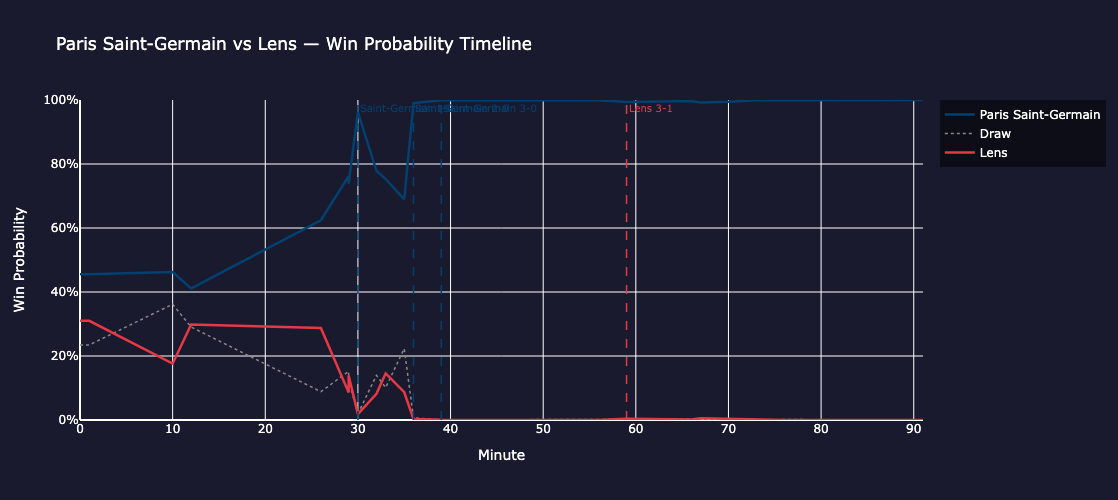

In [99]:

# add kickoff state
kickoff = pd.DataFrame([{
  "minute": 0, "p_home_win": 0.455428, "p_draw": 0.234589,
  "p_away_win": 0.309983, "home_goals": 0, "away_goals": 0,
  "team_name": "", "shot_outcome": ""
}])
tl = pd.concat([kickoff, timeline], ignore_index=True)

# goal events for markers
goals = tl[tl["shot_outcome"] == "Goal"]

fig = go.Figure()

fig.add_trace(go.Scatter(
  x=tl["minute"], y=tl["p_home_win"],
  mode="lines", name=home_team,
  line=dict(color="#004170", width=2.5)
))
fig.add_trace(go.Scatter(
  x=tl["minute"], y=tl["p_draw"],
  mode="lines", name="Draw",
  line=dict(color="#888888", width=1.5, dash="dot")
))
fig.add_trace(go.Scatter(
  x=tl["minute"], y=tl["p_away_win"],
  mode="lines", name=away_team,
  line=dict(color="#e63946", width=2.5)
))

# goal markers
for _, goal in goals.iterrows():
  color = "#004170" if goal["team_name"] == home_team else "#e63946"
  fig.add_vline(
      x=goal["minute"],
      line=dict(color=color, width=1.5, dash="dash"),
      annotation_text=f"{goal['team_name'].split()[-1]} {int(goal['home_goals'])}-{int(goal['away_goals'])}",
      annotation_font=dict(color=color, size=10)
  )

fig.update_layout(
  title=f"{home_team} vs {away_team} — Win Probability Timeline",
  xaxis_title="Minute",
  yaxis_title="Win Probability",
  yaxis=dict(tickformat=".0%", range=[0, 1]),
  plot_bgcolor="#1a1a2e",
  paper_bgcolor="#1a1a2e",
  font=dict(color="white"),
  legend=dict(bgcolor="rgba(0,0,0,0.5)"),
  width=900,
  height=500
)

fig.show()

